In [1]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)
from xgboost import XGBClassifier
from google.colab import drive, userdata

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
print("imports done")

imports done


In [2]:
drive.mount('/content/drive', force_remount=False)

base_path  = '/content/drive/MyDrive/ML/stock-lens/'
data_path  = base_path + 'data/'
model_path = base_path + 'models/'
os.makedirs(model_path, exist_ok=True)
print("paths set")

Mounted at /content/drive
paths set


In [3]:
train = pd.read_csv(data_path + 'train.csv', parse_dates=['date'])
val   = pd.read_csv(data_path + 'val.csv',   parse_dates=['date'])
test  = pd.read_csv(data_path + 'test.csv',  parse_dates=['date'])

print("train:", train.shape, "| val:", val.shape, "| test:", test.shape)

train: (575682, 32) | val: (124525, 32) | test: (126514, 32)


In [4]:
# tightening the neutral threshold so the model sees fewer ambiguous days
# this uses the same real returns already computed in notebook 02 — no synthetic data

def make_label(pct):
    if pct > 0.015:   return 'Up'
    if pct < -0.015:  return 'Down'
    return 'Neutral'

for df in [train, val, test]:
    df['label'] = df['next_day_return'].apply(make_label)

print("train label distribution:")
print(train['label'].value_counts(normalize=True).mul(100).round(1))
print("\nval label distribution:")
print(val['label'].value_counts(normalize=True).mul(100).round(1))
print("\ntest label distribution:")
print(test['label'].value_counts(normalize=True).mul(100).round(1))

train label distribution:
label
Neutral   72.8000
Up        14.5000
Down      12.7000
Name: proportion, dtype: float64

val label distribution:
label
Neutral   72.6000
Down      13.9000
Up        13.5000
Name: proportion, dtype: float64

test label distribution:
label
Neutral   72.8000
Up        14.4000
Down      12.8000
Name: proportion, dtype: float64


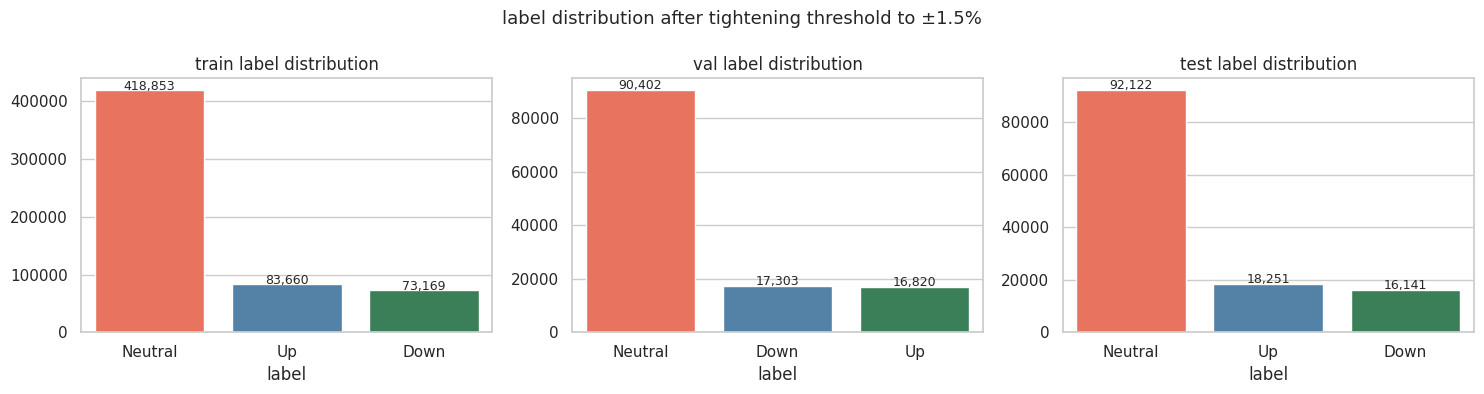

In [5]:
# visualizing how the tighter threshold changed class balance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, df, name in zip(axes, [train, val, test], ['train', 'val', 'test']):
    counts = df['label'].value_counts()
    sns.barplot(x=counts.index, y=counts.values,
                hue=counts.index, palette=['tomato','steelblue','seagreen'],
                legend=False, ax=ax)
    ax.set_title(f'{name} label distribution')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('label distribution after tightening threshold to ±1.5%', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
feature_cols = ['open', 'high', 'low', 'close', 'volume',
                'ma10', 'ma30', 'ma50', 'rsi', 'vol_ratio',
                'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
                'BBU_20_2.0_2.0', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0',
                'Earnings Per Share', 'Total Revenue', 'Net Income',
                'Total Assets', 'Total Liabilities', 'Profit Margin',
                'Total Equity', 'Operating Margin', 'Current Ratio']

X_train, y_train = train[feature_cols], train['label']
X_val,   y_val   = val[feature_cols],   val['label']
X_test,  y_test  = test[feature_cols],  test['label']

print("features:", len(feature_cols))
print("X_train shape:", X_train.shape)

features: 25
X_train shape: (575682, 25)


In [7]:
# imputing nulls with training set median, scaling with training set stats
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

label_encoder = LabelEncoder()
y_train_enc   = label_encoder.fit_transform(y_train)
y_val_enc     = label_encoder.transform(y_val)
y_test_enc    = label_encoder.transform(y_test)

print("preprocessing done")
print("label classes:", label_encoder.classes_)

preprocessing done ✅
label classes: ['Down' 'Neutral' 'Up']


In [8]:
# training random forest with balanced class weights — no synthetic data
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("training random forest...")
rf_model.fit(X_train, y_train_enc)
print("done ✅")

rf_val_preds = rf_model.predict(X_val)
print("\nRandom Forest — validation results:")
print(classification_report(y_val_enc, rf_val_preds, target_names=label_encoder.classes_))

training random forest...
done ✅

Random Forest — validation results:
              precision    recall  f1-score   support

        Down       0.19      0.11      0.13     17303
     Neutral       0.77      0.77      0.77     90402
          Up       0.21      0.31      0.25     16820

    accuracy                           0.62    124525
   macro avg       0.39      0.40      0.39    124525
weighted avg       0.62      0.62      0.61    124525



In [9]:
# computing real sample weights from training labels — no synthetic rows
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

print("training XGBoost...")
xgb_model.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val_enc)],
    verbose=100
)
print("done ✅")

xgb_val_preds = xgb_model.predict(X_val)
print("\nXGBoost — validation results:")
print(classification_report(y_val_enc, xgb_val_preds, target_names=label_encoder.classes_))

training XGBoost...
[0]	validation_0-mlogloss:1.09463
[100]	validation_0-mlogloss:0.99206
[200]	validation_0-mlogloss:0.98433
[299]	validation_0-mlogloss:0.98034
done ✅

XGBoost — validation results:
              precision    recall  f1-score   support

        Down       0.19      0.19      0.19     17303
     Neutral       0.79      0.69      0.74     90402
          Up       0.21      0.36      0.27     16820

    accuracy                           0.58    124525
   macro avg       0.40      0.41      0.40    124525
weighted avg       0.63      0.58      0.60    124525



In [10]:
# training a simple feedforward neural network as a fourth model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    alpha=0.001,
    max_iter=200,
    early_stopping=True,
    random_state=42
)

print("training MLP...")
mlp_model.fit(X_train, y_train_enc)
print("done")

mlp_val_preds = mlp_model.predict(X_val)
print("\nMLP — validation results:")
print(classification_report(y_val_enc, mlp_val_preds, target_names=label_encoder.classes_))

training MLP...
done ✅

MLP — validation results:
              precision    recall  f1-score   support

        Down       0.31      0.02      0.03     17303
     Neutral       0.73      0.99      0.84     90402
          Up       0.30      0.02      0.03     16820

    accuracy                           0.72    124525
   macro avg       0.45      0.34      0.30    124525
weighted avg       0.61      0.72      0.62    124525



In [11]:
# combining RF, XGBoost, and MLP predictions through a logistic regression meta-model
# this often performs better than any single model alone

stacked_model = StackingClassifier(
    estimators=[
        ('rf',  rf_model),
        ('xgb', xgb_model),
        ('mlp', mlp_model)
    ],
    final_estimator=LogisticRegression(max_iter=500),
    n_jobs=-1
)

print("training stacked ensemble — this re-trains base models internally, takes a few minutes...")
stacked_model.fit(X_train, y_train_enc)
print("done")

stacked_val_preds = stacked_model.predict(X_val)
print("\nStacked Ensemble — validation results:")
print(classification_report(y_val_enc, stacked_val_preds, target_names=label_encoder.classes_))

training stacked ensemble — this re-trains base models internally, takes a few minutes...
done ✅

Stacked Ensemble — validation results:
              precision    recall  f1-score   support

        Down       0.32      0.00      0.01     17303
     Neutral       0.73      0.99      0.84     90402
          Up       0.29      0.02      0.04     16820

    accuracy                           0.72    124525
   macro avg       0.44      0.34      0.30    124525
weighted avg       0.61      0.72      0.62    124525



In [12]:
# training one binary classifier per class as a comparison approach
ovr_model = OneVsRestClassifier(
    XGBClassifier(n_estimators=150, max_depth=5, eval_metric='logloss', random_state=42),
    n_jobs=-1
)

print("training one-vs-rest classifiers...")
ovr_model.fit(X_train, y_train_enc)
print("done")

ovr_val_preds = ovr_model.predict(X_val)
print("\nOne-vs-Rest — validation results:")
print(classification_report(y_val_enc, ovr_val_preds, target_names=label_encoder.classes_))

training one-vs-rest classifiers...
done

One-vs-Rest — validation results:
              precision    recall  f1-score   support

        Down       0.28      0.00      0.01     17303
     Neutral       0.73      0.99      0.84     90402
          Up       0.33      0.02      0.04     16820

    accuracy                           0.73    124525
   macro avg       0.45      0.34      0.30    124525
weighted avg       0.61      0.73      0.62    124525



           model  accuracy  macro_f1
   Random Forest    0.6166    0.3865
         XGBoost    0.5757    0.3986
             MLP    0.7241    0.3016
Stacked Ensemble    0.7245    0.2979
     One-vs-Rest    0.7251    0.2983


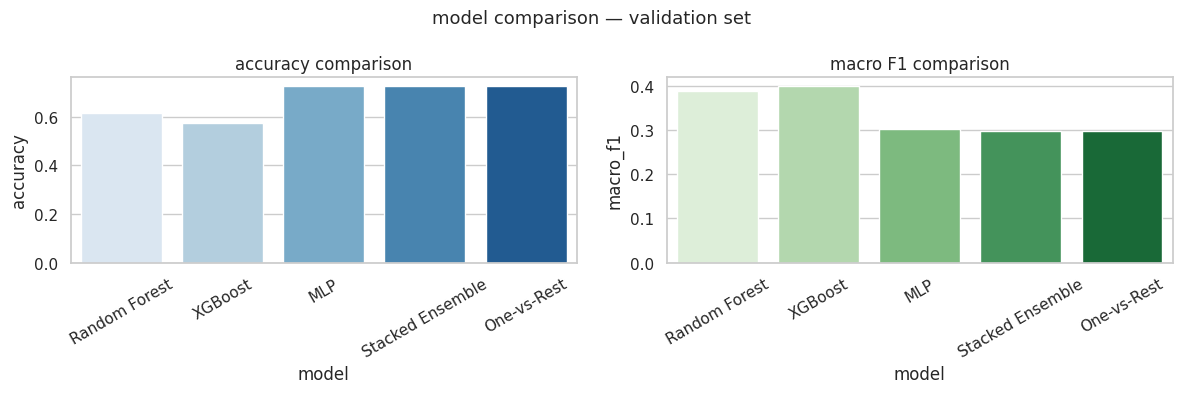

In [13]:
# comparing every model side by side on the validation set
model_results = pd.DataFrame({
    'model': ['Random Forest', 'XGBoost', 'MLP', 'Stacked Ensemble', 'One-vs-Rest'],
    'accuracy': [
        accuracy_score(y_val_enc, rf_val_preds),
        accuracy_score(y_val_enc, xgb_val_preds),
        accuracy_score(y_val_enc, mlp_val_preds),
        accuracy_score(y_val_enc, stacked_val_preds),
        accuracy_score(y_val_enc, ovr_val_preds)
    ],
    'macro_f1': [
        f1_score(y_val_enc, rf_val_preds,      average='macro'),
        f1_score(y_val_enc, xgb_val_preds,     average='macro'),
        f1_score(y_val_enc, mlp_val_preds,     average='macro'),
        f1_score(y_val_enc, stacked_val_preds, average='macro'),
        f1_score(y_val_enc, ovr_val_preds,     average='macro')
    ]
})

print(model_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x='model', y='accuracy', data=model_results, hue='model', legend=False, palette='Blues', ax=axes[0])
axes[0].set_title('accuracy comparison')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x='model', y='macro_f1', data=model_results, hue='model', legend=False, palette='Greens', ax=axes[1])
axes[1].set_title('macro F1 comparison')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('model comparison — validation set', fontsize=13)
plt.tight_layout()
plt.show()

best model on validation: XGBoost

XGBoost — final test set results:
              precision    recall  f1-score   support

        Down       0.18      0.21      0.19     16141
     Neutral       0.81      0.67      0.73     92122
          Up       0.22      0.38      0.28     18251

    accuracy                           0.57    126514
   macro avg       0.40      0.42      0.40    126514
weighted avg       0.64      0.57      0.60    126514



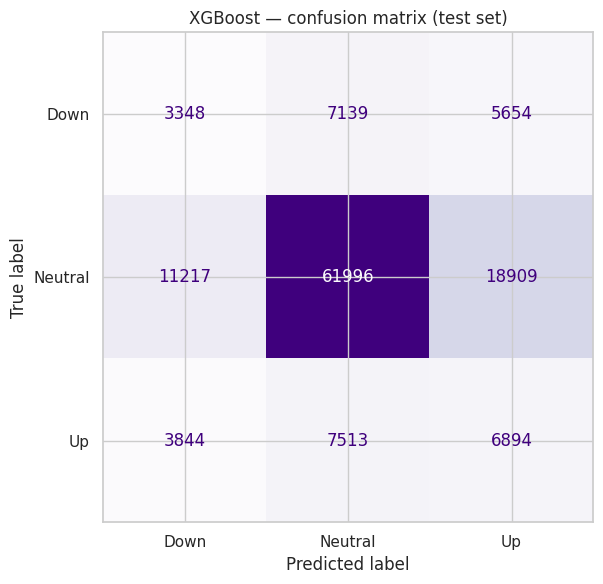

In [14]:
# picking the model with highest macro F1 on validation set and running it once on test
best_model_name = model_results.loc[model_results['macro_f1'].idxmax(), 'model']
print(f"best model on validation: {best_model_name}")

best_model_map = {
    'Random Forest':     rf_model,
    'XGBoost':           xgb_model,
    'MLP':               mlp_model,
    'Stacked Ensemble':  stacked_model,
    'One-vs-Rest':       ovr_model
}
best_model = best_model_map[best_model_name]

test_preds = best_model.predict(X_test)
print(f"\n{best_model_name} — final test set results:")
print(classification_report(y_test_enc, test_preds, target_names=label_encoder.classes_))

cm_test = confusion_matrix(y_test_enc, test_preds)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Purples', colorbar=False)
plt.title(f'{best_model_name} — confusion matrix (test set)')
plt.tight_layout()
plt.show()

In [15]:
# saving every model and preprocessing object for use in later notebooks
artifacts = {
    'rf_model.pkl':       rf_model,
    'xgb_model.pkl':      xgb_model,
    'mlp_model.pkl':      mlp_model,
    'stacked_model.pkl':  stacked_model,
    'ovr_model.pkl':      ovr_model,
    'scaler.pkl':         scaler,
    'imputer.pkl':        imputer,
    'label_encoder.pkl':  label_encoder,
    'feature_cols.pkl':   feature_cols
}

for filename, obj in artifacts.items():
    with open(model_path + filename, 'wb') as f:
        pickle.dump(obj, f)

print("saved all models")
print(os.listdir(model_path))

saved all models ✅
['rf_model.pkl', 'imputer.pkl', 'scaler.pkl', 'feature_cols.pkl', 'label_encoder.pkl', 'xgb_model.pkl', 'mlp_model.pkl', 'stacked_model.pkl', 'ovr_model.pkl']


In [ ]:
import os
import json
from google.colab import drive, _message, userdata

# pulling credentials from colab secrets
github_token = userdata.get('GITHUB_TOKEN')
github_email = userdata.get('GITHUB_EMAIL')
github_name  = userdata.get('GITHUB_NAME')

# saving the notebook to google drive
notebook_name = '03_classification'
notebook_path = f'/content/drive/MyDrive/ML/stock-lens/notebooks/{notebook_name}.ipynb'

notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=120)
with open(notebook_path, 'w') as f:
    json.dump(notebook_json['ipynb'], f)
print("saved to drive")

# installing pdf conversion dependencies
os.system('apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2 -q')
os.system('pip install -q nbconvert[webpdf] playwright')
os.system('playwright install chromium')

# converting notebook to pdf
os.system(f'jupyter nbconvert --to webpdf --allow-chromium-download "{notebook_path}"')
pdf_path = notebook_path.replace('.ipynb', '.pdf')
print("pdf created!!" if os.path.exists(pdf_path) else "pdf creation failed")

# cloning repo if not already present
repo_path = '/content/stock-lens'
if not os.path.exists(repo_path):
    os.system(f'git clone https://github.com/SidRoy97/stock-lens.git {repo_path}')

# creating notebooks folder if missing
os.makedirs(f'{repo_path}/notebooks', exist_ok=True)

# copying notebook and pdf into repo
os.system(f'cp "{notebook_path}" "{repo_path}/notebooks/{notebook_name}.ipynb"')
if os.path.exists(pdf_path):
    os.system(f'cp "{pdf_path}" "{repo_path}/notebooks/{notebook_name}.pdf"')

# configuring git with user credentials
os.system(f'git -C {repo_path} config user.email "{github_email}"')
os.system(f'git -C {repo_path} config user.name "{github_name}"')
os.system(f'git -C {repo_path} add notebooks/')

commit = os.popen(f'git -C {repo_path} commit -m "update {notebook_name} notebook and pdf" 2>&1').read()
print("commit:", commit)

# pushing to github
remote = f'https://{github_token}@github.com/SidRoy97/stock-lens.git'
push   = os.popen(f'git -C {repo_path} push {remote} main 2>&1').read()
print("push:", push)